In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os # File and directory operations
import glob # Search files using wildcard patterns
import h5py # Read HDF5 battery dataset
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
from sklearn.model_selection import train_test_split # For splitting the dataset
from sklearn.linear_model import LinearRegression # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error # Error evaluation

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


# Day 1: One-Feature Baseline Model

This notebook uses the log variance of ΔQ100-10(V) as a single feature to predict battery cycle life with plain linear regression. The goal is to build a simple baseline model using a proper train/test split and report prediction error in cycles and as a percentage.

In [5]:
mat_files_all = glob.glob("/kaggle/input/**/*.mat", recursive=True)

for file in mat_files_all:
    print(file)

/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2017-05-12_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-02-20_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat
/kaggle/input/datasets/itshpark/data-driven-prediction-of-battery-cycle/2018-04-12_batchdata_updated_struct_errorcorrect.mat


In [6]:
mat_files = [
    file for file in mat_files_all
    if "varcharge" not in os.path.basename(file)
]

for file in mat_files:
    print(os.path.basename(file))

2017-05-12_batchdata_updated_struct_errorcorrect.mat
2018-02-20_batchdata_updated_struct_errorcorrect.mat
2018-04-12_batchdata_updated_struct_errorcorrect.mat


In [7]:
def read_scalar_from_ref(f, ref):
    # Read a scalar value stored as an HDF5 reference.
    value = np.array(f[ref]).squeeze()
    return float(value)

In [8]:
def compute_deltaQ_feature(file_path, cell_index):
    cycle_10_index = 9
    cycle_100_index = 99
    
    with h5py.File(file_path, "r") as f:
        # Read cycle life
        cycle_life_ref = f["batch"]["cycle_life"][cell_index, 0]
        cycle_life = read_scalar_from_ref(f, cycle_life_ref)
        
        # Open cycles data
        cycles_ref = f["batch"]["cycles"][cell_index, 0]
        cycles = f[cycles_ref]
        
        # Check if Qdlin exists
        if "Qdlin" not in cycles.keys():
            return None
        
        # Check if this cell has at least 100 cycles
        num_cycles = cycles["Qdlin"].shape[0]
        if num_cycles <= cycle_100_index:
            return None
        
        # Read Qdlin for Cycle 10 and Cycle 100
        Qdlin_10_ref = cycles["Qdlin"][cycle_10_index, 0]
        Qdlin_100_ref = cycles["Qdlin"][cycle_100_index, 0]
        
        Qdlin_10 = np.array(f[Qdlin_10_ref]).squeeze()
        Qdlin_100 = np.array(f[Qdlin_100_ref]).squeeze()
        
        # Check shape
        if Qdlin_10.shape != Qdlin_100.shape:
            return None
        
        # Compute delta Q
        delta_Q = Qdlin_100 - Qdlin_10
        
        # Check missing values
        if np.isnan(delta_Q).sum() > 0:
            return None
        
        # Compute variance and log variance
        var_delta_Q = np.var(delta_Q)
        
        if var_delta_Q <= 0:
            return None
        
        log_var_delta_Q = np.log10(var_delta_Q)
        
        return {
            "batch_file": os.path.basename(file_path),
            "cell_index": cell_index,
            "cycle_life": cycle_life,
            "var_delta_Q": var_delta_Q,
            "log_var_delta_Q": log_var_delta_Q
        }

In [9]:
feature_results = []
skipped_cells = []

for file_path in mat_files:
    batch_name = os.path.basename(file_path)
    
    with h5py.File(file_path, "r") as f:
        num_cells = f["batch"]["cycle_life"].shape[0]
    
    for cell_index in range(num_cells):
        try:
            result = compute_deltaQ_feature(file_path, cell_index)
            
            if result is not None:
                feature_results.append(result)
            else:
                skipped_cells.append({
                    "batch_file": batch_name,
                    "cell_index": cell_index,
                    "reason": "missing data or invalid feature"
                })
                
        except Exception as e:
            skipped_cells.append({
                "batch_file": batch_name,
                "cell_index": cell_index,
                "reason": str(e)
            })

features_df = pd.DataFrame(feature_results)
skipped_df = pd.DataFrame(skipped_cells)

features_df.head()

,batch_file,cell_index,cycle_life,var_delta_Q,log_var_delta_Q
0,2017-05-12_batchdata_updated_struct_errorcorre...,0,1190.0,0.000010,-5.014861
1,2017-05-12_batchdata_updated_struct_errorcorre...,1,1179.0,0.000010,-5.013960
2,2017-05-12_batchdata_updated_struct_errorcorre...,2,1177.0,0.000018,-4.737000
3,2017-05-12_batchdata_updated_struct_errorcorre...,3,1226.0,0.000036,-4.442613
4,2017-05-12_batchdata_updated_struct_errorcorre...,4,1227.0,0.000023,-4.647744


In [8]:
features_df.shape

(139, 5)

In [9]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   batch_file       139 non-null    object 
 1   cell_index       139 non-null    int64  
 2   cycle_life       129 non-null    float64
 3   var_delta_Q      139 non-null    float64
 4   log_var_delta_Q  139 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 5.6+ KB


In [10]:
features_df.isna().sum()

batch_file          0
cell_index          0
cycle_life         10
var_delta_Q         0
log_var_delta_Q     0
dtype: int64

In [11]:
features_df = features_df.dropna()

## Prepare Modeling Dataset

For the Week 5 baseline model, I use only one feature: `log_var_delta_Q`. The target value is `cycle_life`.

In [12]:
model_df = features_df[["log_var_delta_Q", "cycle_life"]].copy()

model_df.head()

,log_var_delta_Q,cycle_life
0,-5.014861,1190.0
1,-5.013960,1179.0
2,-4.737000,1177.0
3,-4.442613,1226.0
4,-4.647744,1227.0


In [13]:
model_df.describe()

,log_var_delta_Q,cycle_life
count,129.000000,129.000000
mean,-3.916885,833.689922
std,0.427685,314.972737
min,-5.098856,392.000000
25%,-4.178878,559.000000
50%,-3.999668,828.000000
75%,-3.516252,1017.000000
max,-3.085882,1935.000000


In [14]:
X = model_df[["log_var_delta_Q"]]
y = model_df["cycle_life"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (129, 1)
y shape: (129,)


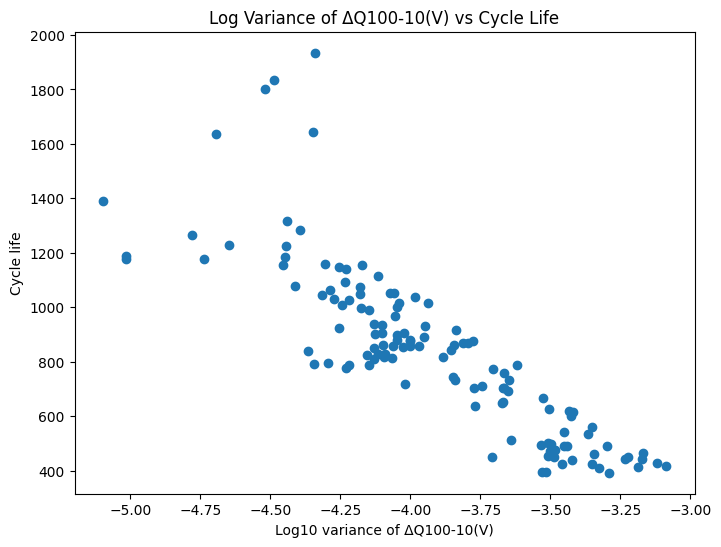

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(model_df["log_var_delta_Q"], model_df["cycle_life"])

plt.xlabel("Log10 variance of ΔQ100-10(V)")
plt.ylabel("Cycle life")
plt.title("Log Variance of ΔQ100-10(V) vs Cycle Life")

plt.show()

### Modeling Dataset Observation

This scatter plot shows the relationship between the one input feature, `log_var_delta_Q`, and the target value, `cycle_life`. The trend appears negative, meaning that cells with larger early-cycle discharge curve changes tend to have shorter cycle lives.

This confirms that `log_var_delta_Q` is a useful feature to test with a simple one-feature linear regression model.

In [16]:
model_df.to_csv("week5_one_feature_model_data.csv", index=False)
features_df.to_csv("week5_deltaQ_features_all_cells.csv", index=False)

In [17]:
os.listdir("/kaggle/working")

['week5_one_feature_model_data.csv',
 'week5_deltaQ_features_all_cells.csv',
 '.virtual_documents']

## Day 2: Train/Test Split and One-Feature Linear Regression

Today, I train the first baseline model using only one feature: `log_var_delta_Q`. The goal is to use plain linear regression to predict battery cycle life and check whether this single feature can produce reasonable predictions.

In [18]:
model_df.head()

,log_var_delta_Q,cycle_life
0,-5.014861,1190.0
1,-5.013960,1179.0
2,-4.737000,1177.0
3,-4.442613,1226.0
4,-4.647744,1227.0


In [18]:
model_df.isna().sum()

log_var_delta_Q    0
cycle_life         0
dtype: int64

In [19]:
X = model_df[["log_var_delta_Q"]]
y = model_df["cycle_life"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (129, 1)
y shape: (129,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (103, 1)
X_test shape: (26, 1)
y_train shape: (103,)
y_test shape: (26,)


In [21]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [22]:
print("Coefficient:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

Coefficient: -643.5276267128997
Intercept: -1675.7146394636386


In [26]:
y_pred = linear_model.predict(X_test)

print(y_pred[:10])

[1120.04330953  933.9267685   653.79541012  755.36067047  962.89377564
  545.03492047  598.81955451  941.09051039 1073.2950469   766.61427792]


In [27]:
results_df = pd.DataFrame({
    "actual_cycle_life": y_test.values,
    "predicted_cycle_life": y_pred
})

results_df["error_cycles"] = results_df["predicted_cycle_life"] - results_df["actual_cycle_life"]
results_df.head()

,actual_cycle_life,predicted_cycle_life,error_cycles
0,791.0,1120.043310,329.043310
1,966.0,933.926769,-32.073231
2,788.0,653.795410,-134.204590
3,876.0,755.360670,-120.639330
4,935.0,962.893776,27.893776


### Actual vs Predicted Cycle Life

This plot compares the actual cycle life values with the predicted cycle life values from the one-feature linear regression model. The model uses only `log_var_delta_Q` as the input feature.

The diagonal line represents perfect prediction, where the predicted cycle life equals the actual cycle life. Points closer to this line indicate better predictions, while points farther away show larger prediction errors.

This plot helps me visually evaluate whether the one-feature baseline model can make reasonable lifetime predictions.

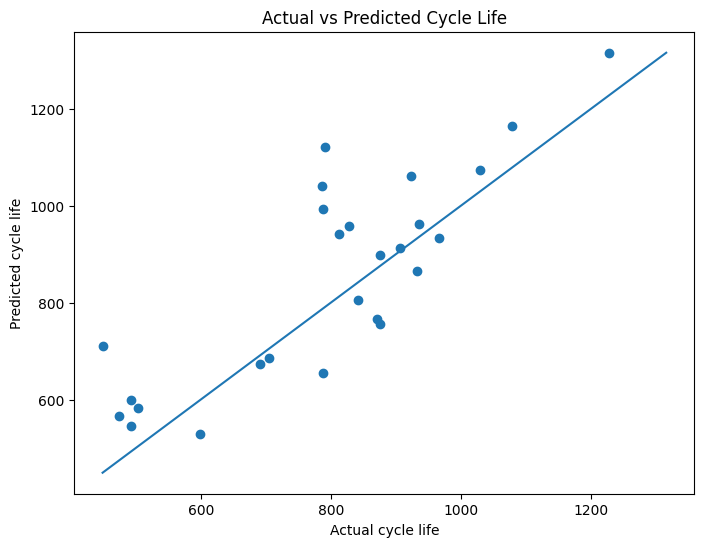

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(results_df["actual_cycle_life"], results_df["predicted_cycle_life"])

min_life = min(results_df["actual_cycle_life"].min(), results_df["predicted_cycle_life"].min())
max_life = max(results_df["actual_cycle_life"].max(), results_df["predicted_cycle_life"].max())

plt.plot([min_life, max_life], [min_life, max_life])

plt.xlabel("Actual cycle life")
plt.ylabel("Predicted cycle life")
plt.title("Actual vs Predicted Cycle Life")

plt.show()

### One-Feature Linear Regression Model

This baseline model uses only one feature, `log_var_delta_Q`, to predict battery cycle life. The model learns a linear relationship between the early-cycle discharge curve change and the final lifetime.

The model equation is:

predicted cycle life = coefficient × log_var_delta_Q + intercept

If the coefficient is negative, it means that larger early-cycle discharge curve changes are associated with shorter predicted cycle life. This matches the main idea from the paper.

## Day 3: Evaluate One-Feature Model Error

Today, I evaluate the one-feature linear regression model. The goal is to report prediction error in cycle units and as a percentage, so I can understand how well the baseline model predicts battery cycle life.

In [24]:
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

y_test shape: (26,)
y_pred shape: (26,)


In [29]:
results_df = pd.DataFrame({
    "actual_cycle_life": y_test.values,
    "predicted_cycle_life": y_pred
})

results_df.head()

,actual_cycle_life,predicted_cycle_life
0,791.0,1120.043310
1,966.0,933.926769
2,788.0,653.795410
3,876.0,755.360670
4,935.0,962.893776


In [30]:
results_df["error_cycles"] = results_df["predicted_cycle_life"] - results_df["actual_cycle_life"]

results_df["absolute_error_cycles"] = abs(results_df["error_cycles"])

results_df["percentage_error"] = (
    results_df["absolute_error_cycles"] / results_df["actual_cycle_life"]
) * 100

results_df.head()

,actual_cycle_life,predicted_cycle_life,error_cycles,absolute_error_cycles,percentage_error
0,791.0,1120.043310,329.043310,329.043310,41.598396
1,966.0,933.926769,-32.073231,32.073231,3.320210
2,788.0,653.795410,-134.204590,134.204590,17.031039
3,876.0,755.360670,-120.639330,120.639330,13.771613
4,935.0,962.893776,27.893776,27.893776,2.983292


In [31]:
# On average, how many cycles off are the model's prediction
mae_cycles = mean_absolute_error(
    results_df["actual_cycle_life"],
    results_df["predicted_cycle_life"]
)

print("MAE in cycles:", mae_cycles)

MAE in cycles: 102.00291012404607


In [32]:
mse = mean_squared_error(
    results_df["actual_cycle_life"],
    results_df["predicted_cycle_life"]
)

# Measures the average prediction error, giving more weight to larger errors, 
# and is expressed in the same units as the target variable
rmse_cycles = np.sqrt(mse)

print("RMSE in cycles:", rmse_cycles)

RMSE in cycles: 129.79696765799338


In [33]:
mean_percentage_error = results_df["percentage_error"].mean()

print("Mean percentage error:", mean_percentage_error)

Mean percentage error: 14.314052456766596


In [34]:
error_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "Mean percentage error"
    ],
    "Value": [
        mae_cycles,
        rmse_cycles,
        mean_percentage_error
    ],
    "Unit": [
        "cycles",
        "cycles",
        "%"
    ]
})

error_table

,Metric,Value,Unit
0,MAE,102.002910,cycles
1,RMSE,129.796968,cycles
2,Mean percentage error,14.314052,%


In [35]:
error_table_rounded = error_table.copy()
error_table_rounded["Value"] = error_table_rounded["Value"].round(2)

error_table_rounded

,Metric,Value,Unit
0,MAE,102.00,cycles
1,RMSE,129.80,cycles
2,Mean percentage error,14.31,%


In [36]:
# Look for cells that got the biggest prediction errors
results_df.sort_values("absolute_error_cycles", ascending=False).head(10)

,actual_cycle_life,predicted_cycle_life,error_cycles,absolute_error_cycles,percentage_error
0,791.0,1120.043310,329.043310,329.043310,41.598396
12,449.0,710.037092,261.037092,261.037092,58.137437
24,786.0,1039.656212,253.656212,253.656212,32.271783
23,788.0,992.927843,204.927843,204.927843,26.006071
22,923.0,1061.503042,138.503042,138.503042,15.005747
2,788.0,653.795410,-134.204590,134.204590,17.031039
18,828.0,957.474122,129.474122,129.474122,15.636971
7,813.0,941.090510,128.090510,128.090510,15.755290
3,876.0,755.360670,-120.639330,120.639330,13.771613
6,493.0,598.819555,105.819555,105.819555,21.464413


### Distribution of prediction errors
A prediction error close to zero means the model predicted the cycle life accurately. A positive error means the model overestimated the cycle life, while a negative error means the model underestimated the cycle life.

This plot helps show whether the model errors are centered around zero and whether there are any large prediction mistakes.


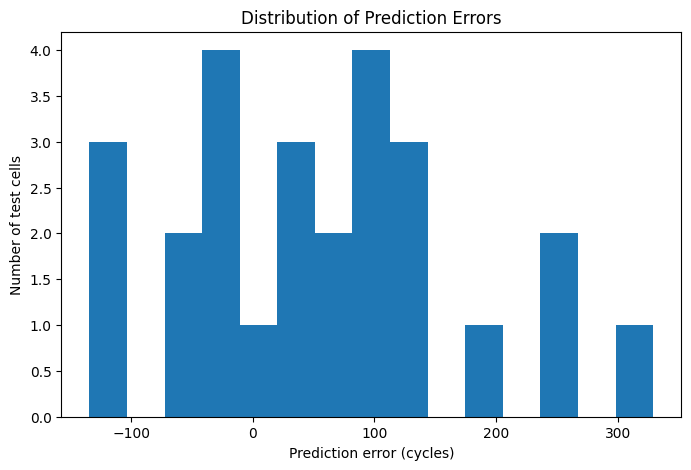

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(results_df["error_cycles"], bins=15)

plt.xlabel("Prediction error (cycles)")
plt.ylabel("Number of test cells")
plt.title("Distribution of Prediction Errors")

plt.show()

### Distribution of Percentage Errors

This histogram shows the percentage error for the one-feature linear regression model. The percentage error measures the prediction error relative to the actual cycle life of each test cell.

This is useful because an error of 100 cycles has a different meaning for a short-life cell than for a long-life cell. By using percentage error, I can better compare model performance across cells with different lifetimes.

This plot helps evaluate whether most test cells have reasonably small prediction errors and whether a few cells have much larger errors.

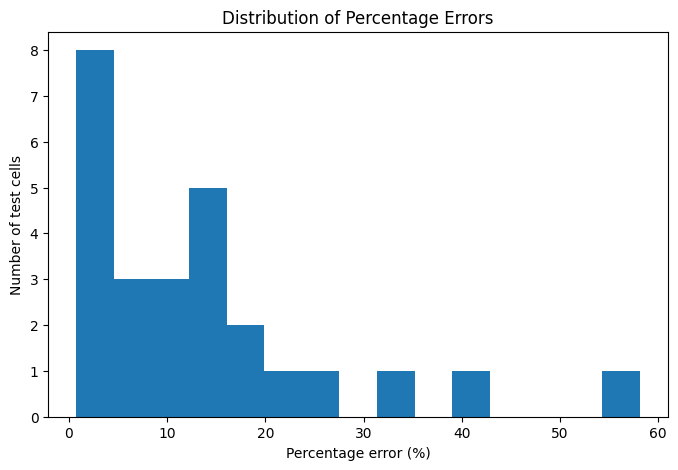

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(results_df["percentage_error"], bins=15)

plt.xlabel("Percentage error (%)")
plt.ylabel("Number of test cells")
plt.title("Distribution of Percentage Errors")

plt.show()

### Model Error Evaluation

I evaluated the one-feature linear regression model using three metrics: MAE, RMSE, and mean percentage error.

MAE shows the average prediction error in cycle units. RMSE also measures error in cycles, but it gives more weight to larger mistakes. Mean percentage error shows the average error as a percentage of the true cycle life.

These metrics help me understand whether the one-feature baseline model performs reasonably and how close it is to the target error range described in the project plan.

### Observation

The one-feature baseline model gives an initial estimate of battery cycle life using only the log variance of ΔQ100-10(V). This is useful because it tests whether one well-designed feature can already capture meaningful lifetime information.

The model is not expected to be perfect, but it provides a simple baseline. Next week, I can compare this one-feature model with a multi-feature model to see whether adding more battery features improves prediction performance.

## Day 4: Explain Model Results and Improve Visualizations

Today, I focus on improving the explanation of the one-feature linear regression model. The goal is to clearly explain the model coefficient, prediction results, error metrics, and why this one-feature model is a useful baseline.

### Model Coefficient Interpretation

The one-feature linear regression model learns a relationship between `log_var_delta_Q` and `cycle_life`.

The model equation is:

predicted cycle life = coefficient × log_var_delta_Q + intercept

If the coefficient is negative, it means that larger early-cycle discharge curve changes are associated with shorter predicted battery lifetime. This matches the main idea of the paper, which suggests that early voltage-capacity curve changes contain useful information about future cycle life.

In [39]:
print("Coefficient:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

Coefficient: -643.5276267128997
Intercept: -1675.7146394636386


### Actual vs Predicted Cycle Life

This plot compares the actual cycle life values with the predicted cycle life values from the one-feature linear regression model. The model uses only `log_var_delta_Q` as the input feature.

The diagonal line represents perfect prediction, where the predicted cycle life equals the actual cycle life. Points closer to this line indicate better predictions, while points farther away show larger prediction errors.

A positive relationship in this graph is expected because cells with higher actual cycle life should ideally have higher predicted cycle life. This plot helps visually evaluate whether the one-feature baseline model makes reasonable predictions.

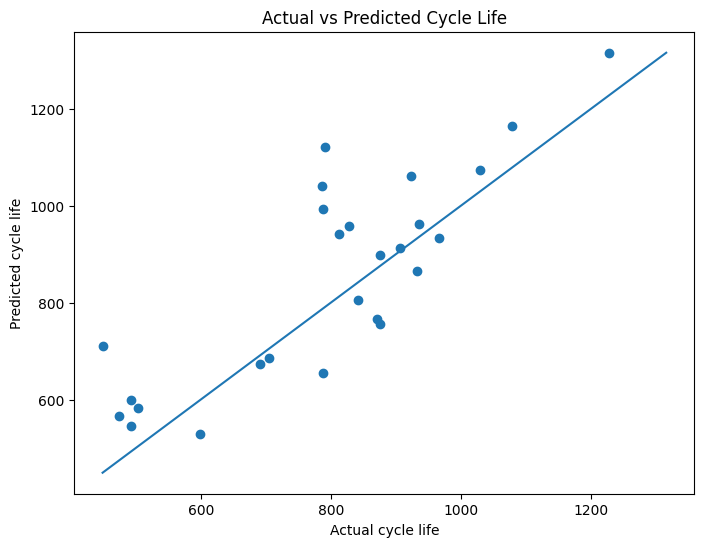

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(results_df["actual_cycle_life"], results_df["predicted_cycle_life"])

min_life = min(
    results_df["actual_cycle_life"].min(),
    results_df["predicted_cycle_life"].min()
)

max_life = max(
    results_df["actual_cycle_life"].max(),
    results_df["predicted_cycle_life"].max()
)

plt.plot([min_life, max_life], [min_life, max_life])

plt.xlabel("Actual cycle life")
plt.ylabel("Predicted cycle life")
plt.title("Actual vs Predicted Cycle Life")

plt.show()

### Error Table

This table summarizes the performance of the one-feature linear regression model.

MAE shows the average prediction error in cycle units. RMSE also measures error in cycles, but it gives more weight to larger mistakes. Mean percentage error shows the average prediction error relative to the actual battery lifetime.

These metrics help evaluate whether the one-feature baseline model performs reasonably before adding more features in the multi-feature model.

In [41]:
error_table_rounded

,Metric,Value,Unit
0,MAE,102.00,cycles
1,RMSE,129.80,cycles
2,Mean percentage error,14.31,%


### Comparison with Week 5 Target

The project prompt says that a realistic target is low-to-mid-teens percent error. My one-feature model has a mean percentage error of about 14.31%.

This result gives me a baseline to compare against the Week 6 multi-feature model. Even if the one-feature model is not perfect, it is useful because it shows how much predictive power can come from one carefully designed feature.

### Distribution of Percentage Errors

This histogram shows the percentage error for the one-feature linear regression model. The percentage error measures the prediction error relative to the actual cycle life of each test cell.

This is useful because an error of 100 cycles has a different meaning for a short-life cell than for a long-life cell. By using percentage error, I can compare model performance across cells with different lifetimes.

This plot helps evaluate whether most test cells have reasonably small prediction errors or whether a few cells have much larger errors.

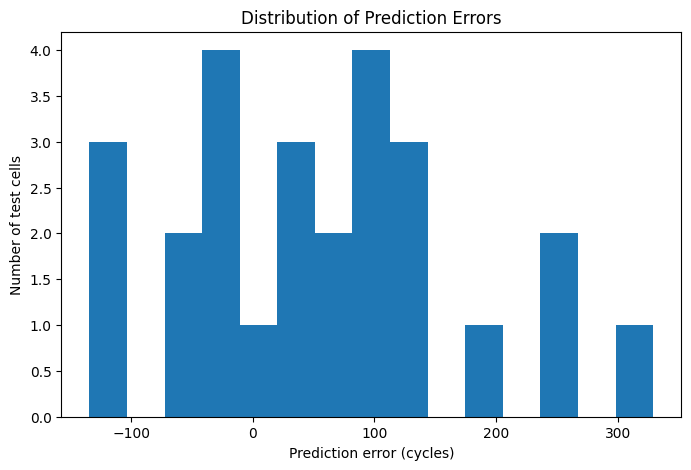

In [42]:
plt.figure(figsize=(8, 5))

plt.hist(results_df["error_cycles"], bins=15)

plt.xlabel("Prediction error (cycles)")
plt.ylabel("Number of test cells")
plt.title("Distribution of Prediction Errors")

plt.show()

### Distribution of Percentage Errors

This histogram shows the percentage error for the one-feature linear regression model. The percentage error measures the prediction error relative to the actual cycle life of each test cell.

This is useful because an error of 100 cycles has a different meaning for a short-life cell than for a long-life cell. By using percentage error, I can compare model performance across cells with different lifetimes.

This plot helps evaluate whether most test cells have reasonably small prediction errors or whether a few cells have much larger errors.

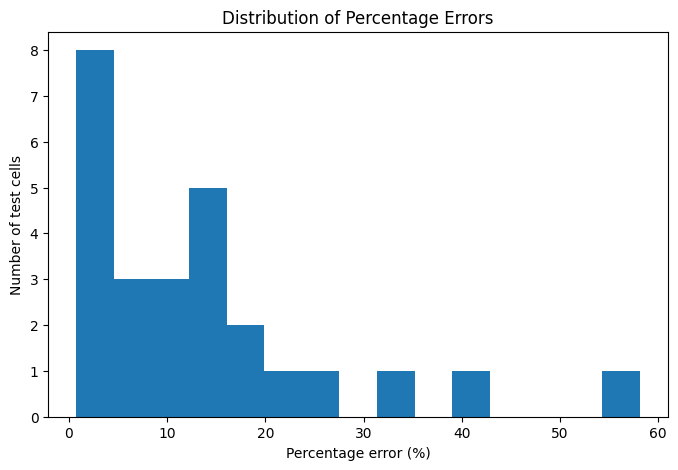

In [43]:
plt.figure(figsize=(8, 5))

plt.hist(results_df["percentage_error"], bins=15)

plt.xlabel("Percentage error (%)")
plt.ylabel("Number of test cells")
plt.title("Distribution of Percentage Errors")

plt.show()

### Largest Prediction Errors

This table shows the test cells with the largest absolute prediction errors. Looking at the largest errors helps identify where the one-feature model performs poorly.

Since this model uses only one feature, it may not capture all battery aging behavior. Some cells may require additional features, such as early discharge capacity, capacity fade slope, charge time, or internal resistance.

In [44]:
results_df.sort_values("absolute_error_cycles", ascending=False).head(10)

,actual_cycle_life,predicted_cycle_life,error_cycles,absolute_error_cycles,percentage_error
0,791.0,1120.043310,329.043310,329.043310,41.598396
12,449.0,710.037092,261.037092,261.037092,58.137437
24,786.0,1039.656212,253.656212,253.656212,32.271783
23,788.0,992.927843,204.927843,204.927843,26.006071
22,923.0,1061.503042,138.503042,138.503042,15.005747
2,788.0,653.795410,-134.204590,134.204590,17.031039
18,828.0,957.474122,129.474122,129.474122,15.636971
7,813.0,941.090510,128.090510,128.090510,15.755290
3,876.0,755.360670,-120.639330,120.639330,13.771613
6,493.0,598.819555,105.819555,105.819555,21.464413


### Day 4 Observation

Today, I improved the explanation of the one-feature baseline model. I reviewed the model coefficient, actual-vs-predicted plot, error table, and error distributions.

This model is useful as a baseline because it uses only one feature, `log_var_delta_Q`, to predict cycle life. The results show how much predictive information can come from the early-cycle discharge curve change alone.

The model is not expected to be perfect, but it provides an important comparison point for Week 6, when I will add more features and train a richer model.

## Day 5: Notebook Cleanup and Final Summary

Today, I clean and organize the Week 5 one-feature baseline model notebook. The goal is to make sure the notebook clearly shows the full modeling workflow, including feature preparation, train/test split, linear regression, predictions, error evaluation, and final observations.

### Final Model Summary

This baseline model uses plain linear regression with only one input feature: `log_var_delta_Q`. The target value is `cycle_life`.

The model learns a simple linear relationship:

predicted cycle life = coefficient × log_var_delta_Q + intercept

This model is intentionally simple. The goal is not to build the best model yet, but to test whether one strong feature from the paper can already predict battery lifetime reasonably well.

In [45]:
coefficient = linear_model.coef_[0]
intercept = linear_model.intercept_

model_summary_table = pd.DataFrame({
    "Item": [
        "Model",
        "Input feature",
        "Target",
        "Coefficient",
        "Intercept"
    ],
    "Value": [
        "Linear Regression",
        "log_var_delta_Q",
        "cycle_life",
        coefficient,
        intercept
    ]
})

model_summary_table

,Item,Value
0,Model,Linear Regression
1,Input feature,log_var_delta_Q
2,Target,cycle_life
3,Coefficient,-643.527627
4,Intercept,-1675.714639


## Final Observations for this week

This week, I built a one-feature baseline model to predict battery cycle life. The input feature was `log_var_delta_Q`, which represents the log variance of the discharge curve change between Cycle 100 and Cycle 10. The target value was `cycle_life`.

I used a proper train/test split and trained a plain linear regression model. Then I evaluated the model using MAE, RMSE, and mean percentage error. These metrics helped me understand the model error in both cycle units and percentage.

The one-feature model is useful because it shows that a single well-designed feature can already capture meaningful information about battery lifetime. This supports the project idea that good features can be more important than using a complicated model. In Week 6, I can compare this baseline with a multi-feature model to see whether adding more battery features improves prediction performance.